In [20]:
from github_helper import from_github
import pandas as pd
from tqdm import tqdm
import numpy as np
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
edge_df = pd.read_csv(from_github("/edges/party/all_party_edges_by_Period.csv"))

edge_df = edge_df[edge_df['Period']!=65]
edge_df.head()

#We drop Period 65, as it does not seem to be representative. It should be done in "enriched_votes_calculations"


,source,target,Period,total_votes_shared,total_votes_agreed,weight,topic
44,Dansk Folkeparti,Dansk Folkeparti,66,19793,19771.0,0.998888,klima_miljø
45,Dansk Folkeparti,Det Konservative Folkeparti,66,30446,29104.0,0.955922,klima_miljø
46,Dansk Folkeparti,Enhedslisten,66,3456,861.0,0.249132,klima_miljø
47,Dansk Folkeparti,Inuit Ataqatigiit,66,41,14.0,0.341463,klima_miljø
48,Dansk Folkeparti,Liberal Alliance,66,22,0.0,0.000000,klima_miljø


In [47]:
traditional_parties = ["Det Konservative Folkeparti", "Enhedslisten", "Liberal Alliance", "Radikale Venstre", "Socialdemokratiet", "Socialistisk Folkeparti", "Venstre", "Dansk Folkeparti"]
mask_only_traditional_parties = (edge_df['source'].isin(traditional_parties)) & (edge_df['target'].isin(traditional_parties))
edge_traditional = edge_df[mask_only_traditional_parties]

In [61]:
#We drop all observations, where the parties share less than 20 votes in a year, as this is not representative of the party.
#Example: In period 66, LA has agreement with a lot of parties on a lot of topics, because they share very few votes.
# edge_limited = edge_traditional[edge_traditional['total_votes_shared']>25] #OR WE COULD DROP LA IN PERIOD 66?
# Let's do a scatterplot, just for LA in period 66 to justify
# edge_limited = edge_traditional
mask_la_in_66 = ((edge_traditional['source'] == "Liberal Alliance") | (edge_traditional['target'] == "Liberal Alliance")) & (edge_traditional['Period']==66) #Use this mask to show

edge_limited = edge_traditional[~mask_la_in_66] 
edge_limited

,source,target,Period,total_votes_shared,total_votes_agreed,weight,topic
44,Dansk Folkeparti,Dansk Folkeparti,66,19793,19771.0,0.998888,klima_miljø
45,Dansk Folkeparti,Det Konservative Folkeparti,66,30446,29104.0,0.955922,klima_miljø
46,Dansk Folkeparti,Enhedslisten,66,3456,861.0,0.249132,klima_miljø
49,Dansk Folkeparti,Radikale Venstre,66,11032,6139.0,0.556472,klima_miljø
51,Dansk Folkeparti,Socialdemokratiet,66,29024,14488.0,0.499173,klima_miljø
...,...,...,...,...,...,...,...
8427,Socialdemokratiet,Socialistisk Folkeparti,71,200624,146505.0,0.730247,general
8429,Socialdemokratiet,Venstre,71,197147,197012.0,0.999315,general
8430,Socialistisk Folkeparti,Socialistisk Folkeparti,71,30171,30101.0,0.997680,general
8432,Socialistisk Folkeparti,Venstre,71,67450,49140.0,0.728540,general


In [62]:
periods = [66, 67, 68, 69, 70, 71]
wide = (
    edge_limited
    .pivot_table(
        index=['source', 'target', 'topic'],  # one row per pair+topic
        columns='Period',                     # one column per period
        values='weight',                      # values to fill
        aggfunc='first'                       # or 'mean' if you can have duplicates
    )
    .reindex(columns=periods)                 # ensure column order 65..71
)

# make Period columns normal columns instead of a MultiIndex
wide = wide.reset_index()
wide

Period,source,target,topic,66,67,68,69,70,71
0,Dansk Folkeparti,Dansk Folkeparti,arbejdsmarked_velfærd,0.998932,0.999645,0.995007,0.999326,0.994265,0.997028
1,Dansk Folkeparti,Dansk Folkeparti,bolig,0.999122,1.000000,0.998318,0.999467,0.996733,1.000000
2,Dansk Folkeparti,Dansk Folkeparti,erhverv,0.998377,0.999154,0.996710,0.999835,0.995994,0.995215
3,Dansk Folkeparti,Dansk Folkeparti,finans_budget,0.999654,0.999694,0.998686,0.999574,0.995102,0.997927
4,Dansk Folkeparti,Dansk Folkeparti,forsvar_sikkerhed,0.997925,0.998888,1.000000,0.999057,0.994372,1.000000
...,...,...,...,...,...,...,...,...,...
535,Venstre,Venstre,social_familie,0.979675,0.997794,0.999292,0.999861,0.997226,0.997713
536,Venstre,Venstre,sundhed,0.979487,0.999533,0.998747,0.999778,0.998071,0.997980
537,Venstre,Venstre,transport_infrastruktur,0.999017,0.998709,0.999173,0.999502,0.996881,1.000000
538,Venstre,Venstre,uddannelse,0.973152,0.999781,0.998122,0.999467,0.998912,0.999083


In [72]:
diffs = []
for a, b in combinations(periods, 2):
    # Compute difference but set it to NaN if either side is NaN
    diff = (wide[a] - wide[b]).abs()
    
    # mask invalid diffs where one or both values were missing
    invalid_mask = wide[[a, b]].isna().any(axis=1)
    diff[invalid_mask] = np.nan
    
    diffs.append(diff)

# Combine while ignoring NaN values
wide["biggest_change"] = np.nanmax(np.column_stack(diffs), axis=1)
wide_sorted = wide.sort_values("biggest_change", ascending=False)
wide_sorted

Period,source,target,topic,66,67,68,69,70,71,biggest_change
111,Dansk Folkeparti,Venstre,immigration,0.902200,0.889825,0.633818,0.672116,0.608949,0.247143,0.655057
306,Enhedslisten,Venstre,immigration,0.233660,0.239641,0.396029,0.344502,0.461887,0.720393,0.486733
483,Socialdemokratiet,Venstre,finans_budget,0.580948,0.520237,0.629620,0.695106,0.665719,0.999296,0.479059
21,Dansk Folkeparti,Det Konservative Folkeparti,immigration,0.905337,0.890539,0.641948,0.678489,0.653414,0.429249,0.476088
491,Socialdemokratiet,Venstre,sundhed,0.570606,0.530276,0.745471,0.853179,0.759318,0.998868,0.468592
...,...,...,...,...,...,...,...,...,...,...
532,Venstre,Venstre,klima_miljø,0.998005,0.999725,0.998398,1.000000,0.999615,0.999286,0.001995
534,Venstre,Venstre,skat,0.999266,0.999657,0.998282,0.999362,0.998333,0.998282,0.001375
120,Det Konservative Folkeparti,Det Konservative Folkeparti,arbejdsmarked_velfærd,1.000000,0.999696,0.998725,0.999226,0.998868,1.000000,0.001275
452,Socialdemokratiet,Socialdemokratiet,erhverv,0.998712,0.999405,0.999588,0.999399,0.999409,0.999751,0.001039


<Axes: xlabel='biggest_change', ylabel='Count'>

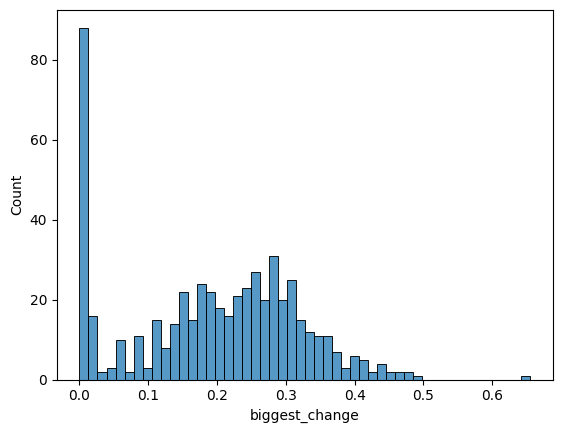

In [73]:
sns.histplot(
    data = wide_sorted
    ,x = "biggest_change"
    ,bins = 50
)

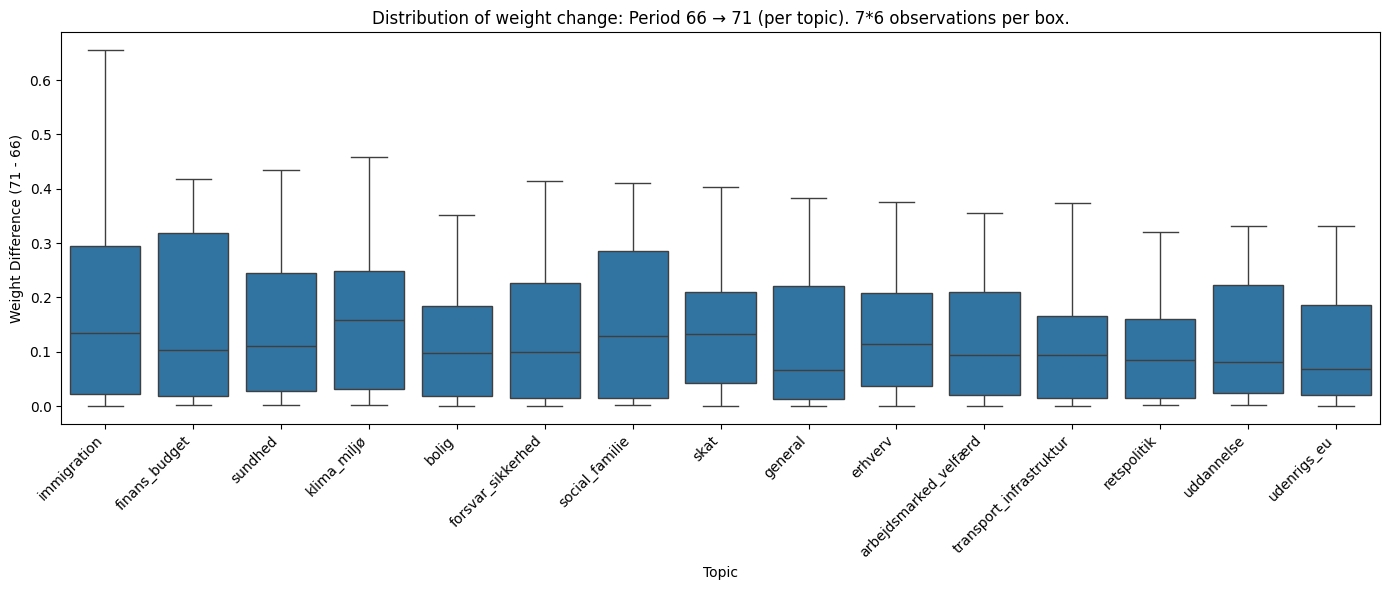

In [74]:
wide_sorted["diff_66_71"] = (wide_sorted[71] - wide_sorted[66]).abs()

# medians = wide_sorted.groupby("topic")["diff_66_71"].mean().sort_values()
# wide_sorted["topic"] = pd.Categorical(
#     wide_sorted["topic"],
#     categories=medians.index,
#     ordered=True
# )


plt.figure(figsize=(14, 6))

sns.boxplot(
    data=wide_sorted,
    x="topic",
    y="diff_66_71",
)

plt.xticks(rotation=45, ha="right")
plt.title("Distribution of weight change: Period 66 → 71 (per topic). 7*6 observations per box.")
plt.xlabel("Topic")
plt.ylabel("Weight Difference (71 - 66)")

plt.tight_layout()
plt.show()